Conectividad

(np.float64(-0.5), np.float64(937.5), np.float64(1208.5), np.float64(-0.5))

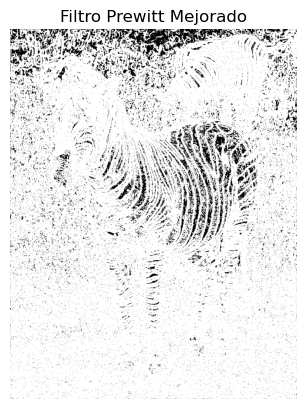

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

imagen = 'zebra.jpg'
img = cv2.imread(imagen)

def filtro_prewitt_mejorado(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suavizar=cv2.GaussianBlur(img_gris,(3,3),0)

    kernel_x=np.array([[-3,0,3],[-3,0,3],[-3,0,3]],dtype=np.float32)
    kernel_y=np.array([[3,3,3],[0,0,0],[-3,-3,-3]],dtype=np.float32)
    grad_x=cv2.filter2D(suavizar,cv2.CV_64F,kernel_x)
    grad_y=cv2.filter2D(suavizar,cv2.CV_64F,kernel_y)
    magnitud=np.sqrt(grad_x**2 + grad_y**2)
    prewitt=cv2.addWeighted(np.abs(grad_x),0.7,np.abs(grad_y),0.7,0)
    _,bordes=cv2.threshold(magnitud,20,255,cv2.THRESH_BINARY)
    return bordes
img = cv2.imread(imagen)
prewitt_result = filtro_prewitt_mejorado(img)
plt.imshow(prewitt_result, cmap='gray')
plt.title('Filtro Prewitt Mejorado')
plt.axis('off')

Conteo

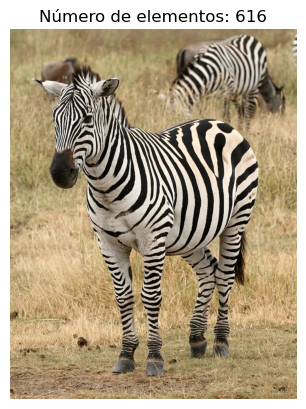

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    e_img = measure.label(binary, connectivity=2)
    num_elementos = np.max(e_img)
    return num_elementos

imagen = 'zebra.jpg'
img = cv2.imread(imagen)
num_elementos = contar_elementos(img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Número de elementos: {num_elementos}')
plt.axis('off')
plt.show()



Canny mejorado

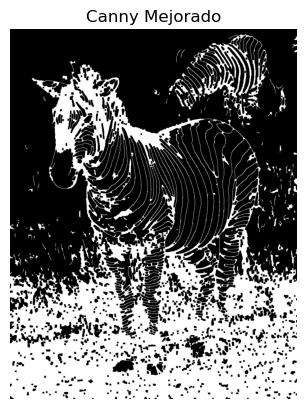

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def filtro_canny_mejorado(img,umbral_bajo=100, umbral_alto=200):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bordes = cv2.Canny(img_gris, umbral_bajo, umbral_alto)
    kernel_m = np.ones((5,5),np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)
    return bordes
img = cv2.imread(imagen)
canny_result = filtro_canny_mejorado(img)
plt.imshow(canny_result, cmap='gray')
plt.title('Canny Mejorado')
plt.axis('off')
plt.show()

Regiones ?

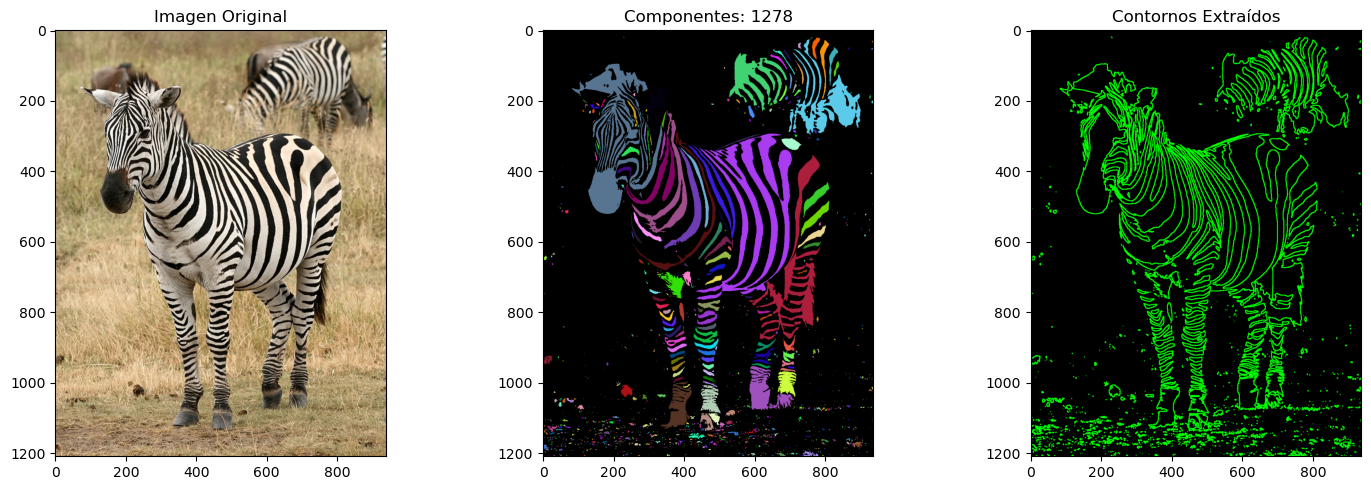

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen
imagen = 'zebra.jpg'
img = cv2.imread(imagen) 
if img is None:
    print("Error: No se pudo cargar la imagen. Revisa la ruta.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Preprocesamiento
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    # cv2.threshold devuelve una tupla (ret, thresh), necesitamos el segundo valor [1]
    _, binary = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Componentes conectados
    # num_labels es el conteo, labels es la matriz etiquetada
    num_labels, labels = cv2.connectedComponents(binary)

    # 4. Colorear componentes
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  # Fondo negro
    colorear = colors[labels]

    # 5. Encontrar contornos
    # findContours devuelve una tupla; los contornos están en el índice [0]
    contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contorno_fin = cv2.drawContours(np.zeros_like(img), contornos, -1, (0, 255, 0), 2)

    # 6. Visualización
    plt.figure(figsize=(15, 5))

    plt.subplot(131)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagen Original')

    plt.subplot(132)
    # Colorear ya está en formato RGB/BGR dependiendo de cómo lo definas, 
    # pero matplotlib espera RGB.
    plt.imshow(cv2.cvtColor(colorear, cv2.COLOR_BGR2RGB))
    plt.title(f'Componentes: {num_labels - 1}')

    plt.subplot(133)
    plt.imshow(cv2.cvtColor(contorno_fin, cv2.COLOR_BGR2RGB))
    plt.title('Contornos Extraídos')

    plt.tight_layout()
    plt.show() # Faltaban los paréntesis ()

Componentes por color

Total componentes distribuidos: 1278 / 1278


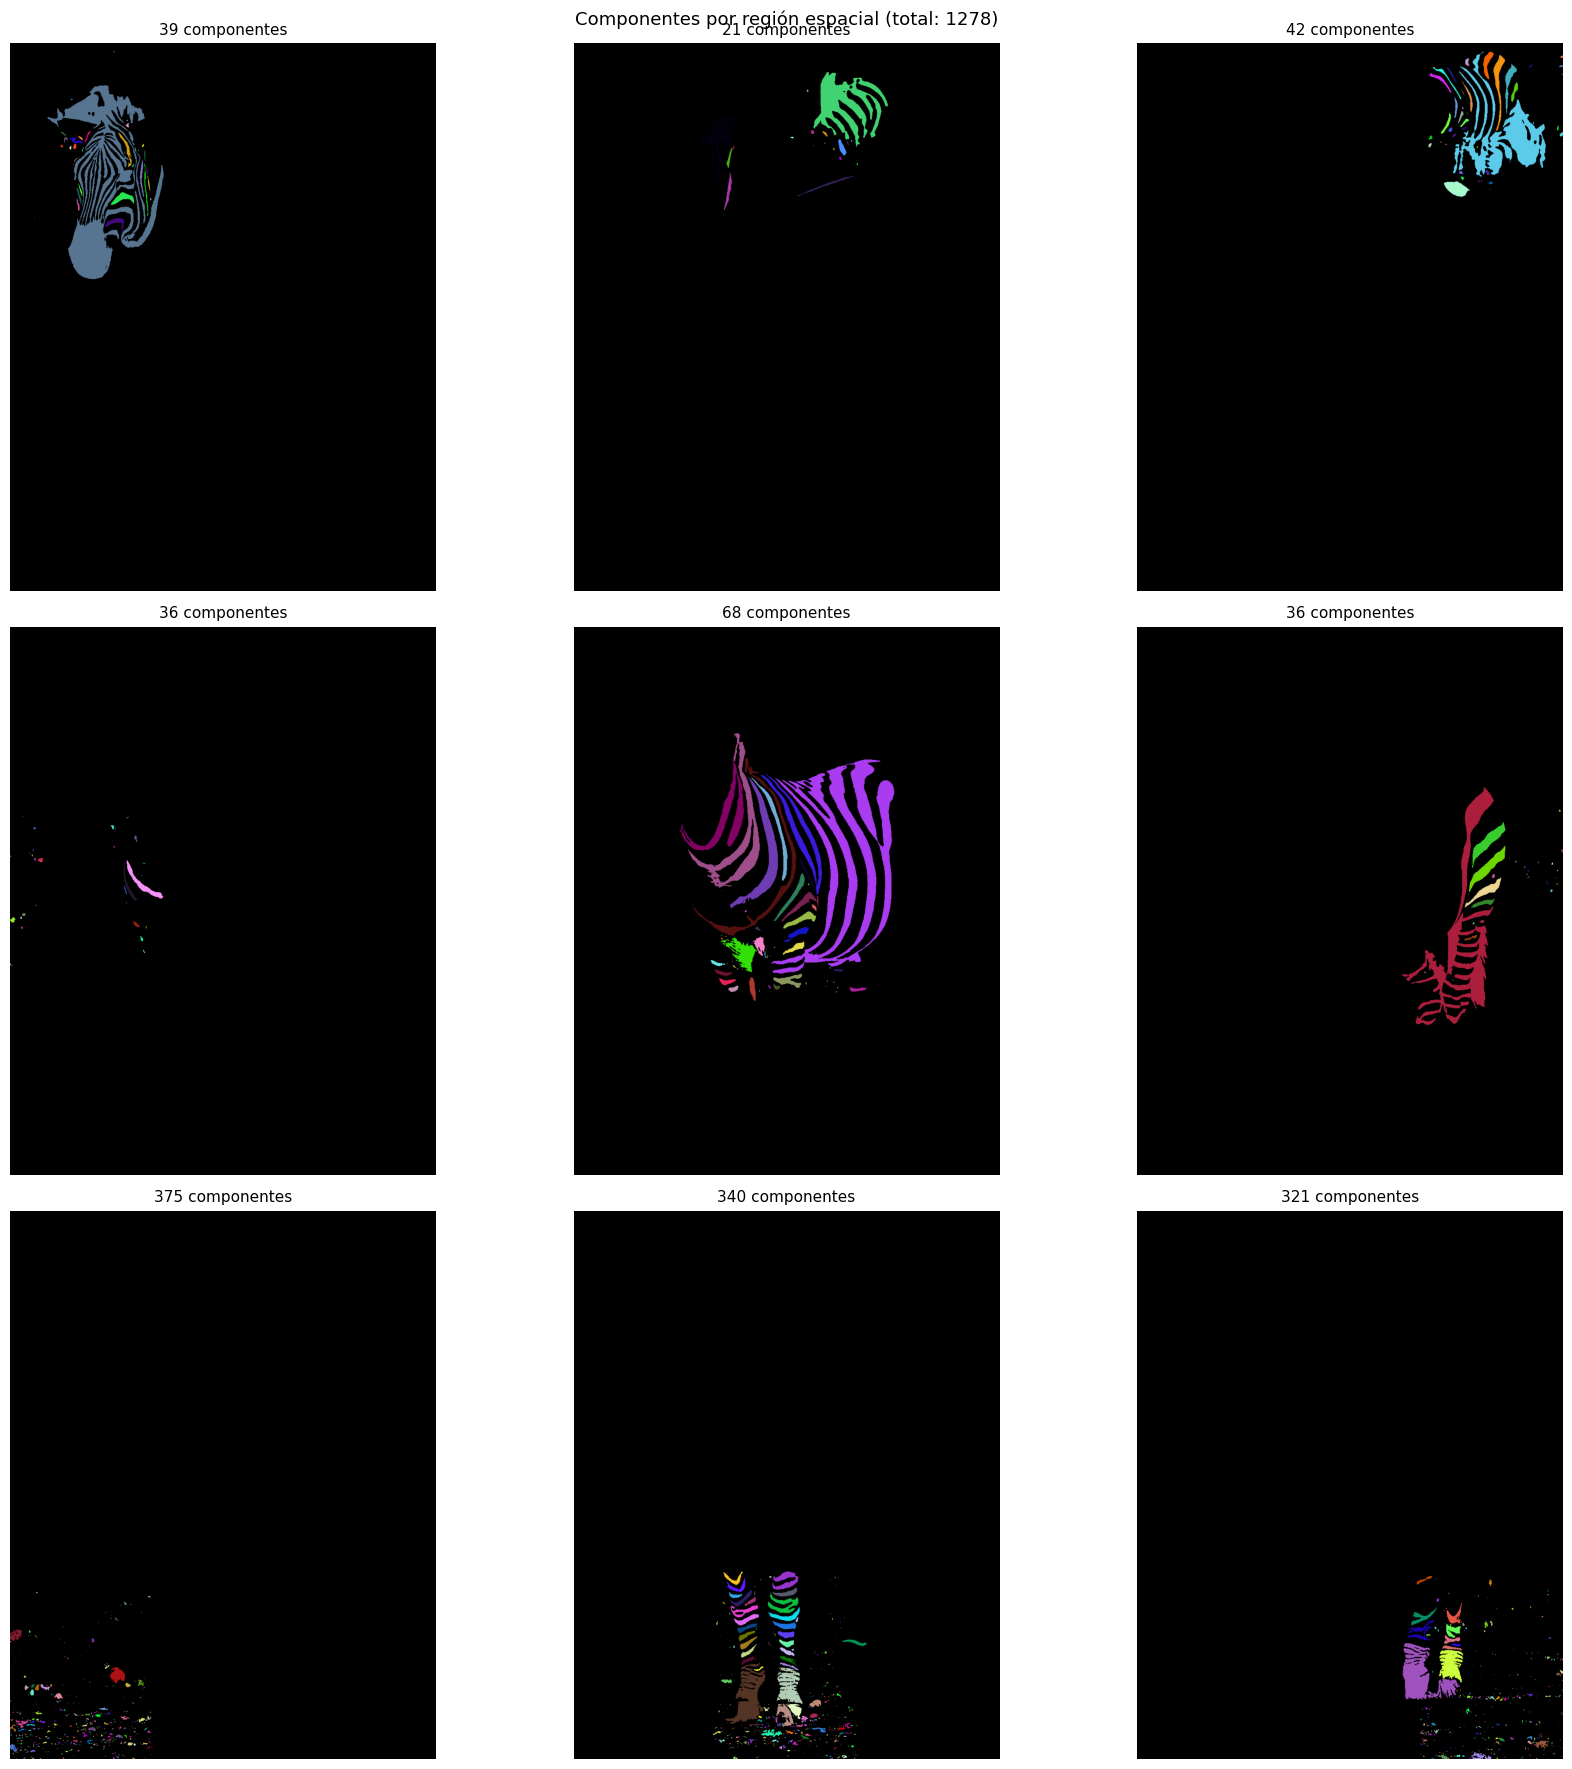

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen
imagen = 'zebra.jpg'
img = cv2.imread(imagen)
if img is None:
    print("Error: No se pudo cargar la imagen. Revisa la ruta.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Preprocesamiento
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    _, binary = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Componentes conectados
    num_labels, labels = cv2.connectedComponents(binary)

    # 4. Colores (misma semilla)
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  # Fondo negro

    # 5. Dividir la imagen en una cuadrícula (grid_rows x grid_cols celdas)
    grid_rows, grid_cols = 3, 3
    h, w = img.shape[:2]
    cell_h = h // grid_rows
    cell_w = w // grid_cols

    # 6. Para cada celda, contar y dibujar los componentes cuyo centroide cae dentro
    # Calcular centroide de cada componente (label 0 = fondo, se ignora)
    from scipy import ndimage
    centroids = ndimage.center_of_mass(np.ones_like(labels), labels, range(1, num_labels))
    # centroids[i] = (cy, cx) del componente i+1

    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 6, grid_rows * 6))

    total_mostrado = 0
    for r in range(grid_rows):
        for c in range(grid_cols):
            y0, y1 = r * cell_h, (r + 1) * cell_h if r < grid_rows - 1 else h
            x0, x1 = c * cell_w, (c + 1) * cell_w if c < grid_cols - 1 else w

            # Componentes cuyo centroide cae en esta celda
            comp_celda = [
                lbl for lbl, (cy, cx) in enumerate(centroids, start=1)
                if y0 <= cy < y1 and x0 <= cx < x1
            ]

            # Dibujar solo esos componentes sobre fondo negro
            img_celda = np.zeros_like(img)
            for lbl in comp_celda:
                mask = labels == lbl
                img_celda[mask] = colors[lbl]

            count = len(comp_celda)
            total_mostrado += count
            axes[r][c].imshow(cv2.cvtColor(img_celda, cv2.COLOR_BGR2RGB))
            axes[r][c].set_title(f'{count} componentes', fontsize=11)
            axes[r][c].axis('off')

    print(f"Total componentes distribuidos: {total_mostrado} / {num_labels - 1}")
    plt.suptitle(f'Componentes por región espacial (total: {total_mostrado})', fontsize=13)
    plt.tight_layout()
    plt.show()


Practica

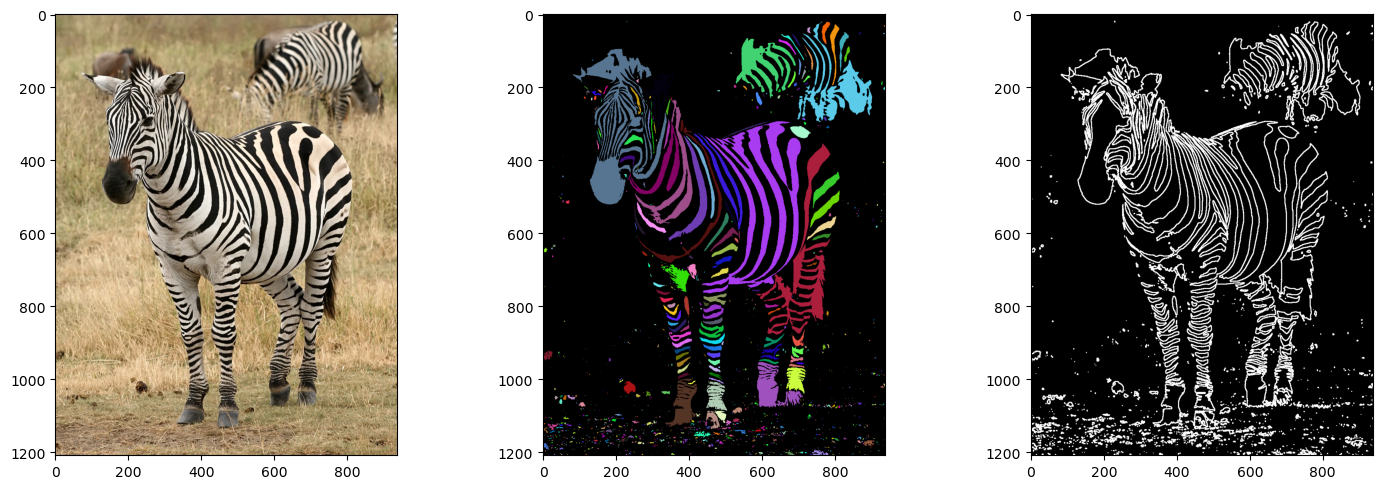

Totalll regiones 1278

color 95, 179, 61 objetos 5
color 234, 203, 92 objetos 15652
color 3, 98, 243 objetos 603
color 14, 149, 245 objetos 1203
color 46, 106, 244 objetos 25
color 99, 187, 71 objetos 1
color 212, 153, 199 objetos 102
color 188, 174, 65 objetos 816
color 153, 20, 44 objetos 25
color 203, 152, 102 objetos 24
color 214, 240, 39 objetos 317
color 121, 24, 34 objetos 139
color 114, 210, 65 objetos 10204
color 239, 39, 214 objetos 331
color 244, 151, 25 objetos 5
color 74, 145, 222 objetos 256
color 14, 202, 85 objetos 274
color 145, 117, 87 objetos 31744
color 184, 189, 221 objetos 12
color 116, 237, 109 objetos 2
color 85, 99, 172 objetos 13
color 226, 153, 103 objetos 169
color 235, 146, 36 objetos 10
color 151, 62, 68 objetos 3
color 181, 130, 160 objetos 12
color 160, 166, 149 objetos 108
color 6, 69, 5 objetos 16
color 52, 253, 112 objetos 241
color 14, 1, 3 objetos 3837
color 76, 248, 87 objetos 112
color 233, 212, 184 objetos 5
color 235, 245, 26 objetos 9
color 213

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen
imagen = 'zebra.jpg'
img = cv2.imread(imagen)
if img is None:
    print("Error: No se pudo cargar la imagen.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Preprocesamiento
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    _, binary = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Componentes conectados
    num_labels, labels = cv2.connectedComponents(binary)

    # 4. Colorear cada componente con un color aleatorio
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  # Fondo negro
    colorear = colors[labels]

    # 5. Contornos en blanco sobre fondo negro
    contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contorno_fin = cv2.drawContours(np.zeros_like(img), contornos, -1, (255, 255, 255), 2)

    # 6. Mostrar las tres imágenes
    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.subplot(132)
    plt.imshow(cv2.cvtColor(colorear, cv2.COLOR_BGR2RGB))
    plt.subplot(133)
    plt.imshow(cv2.cvtColor(contorno_fin, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()

    # 7. Imprimir total de regiones y detalles por color
    print(f"Totalll regiones {num_labels - 1}")
    print()
    for lbl in range(1, num_labels):
        r, g, b = colors[lbl]
        count = int(np.sum(labels == lbl))
        print(f"color {r}, {g}, {b} objetos {count}")
